In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Read the colour image
img_bgr = cv2.imread("/content/image.jpg")
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

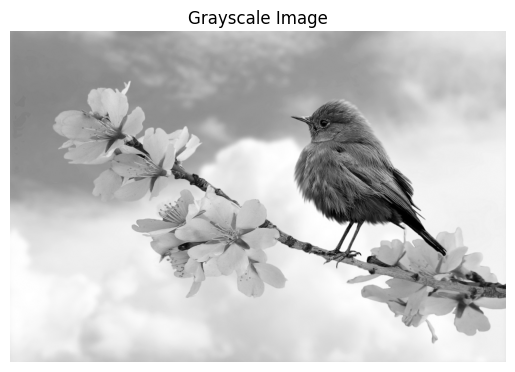

In [ ]:
# Convert to grayscale
img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

plt.imshow(img_gray, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

In [ ]:
# Sobel X and Y kernels
sobel_x = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
])

sobel_y = np.array([
    [-1, -2, -1],
    [ 0,  0,  0],
    [ 1,  2,  1]
])

In [ ]:
# Function to apply a 3x3 kernel manually via sliding window convolution
def convolve_3x3(src_img, kernel):

    h, w = src_img.shape

    padded = np.pad(src_img, 1, mode="edge")
    out = np.zeros((h, w))

    for i in range(h):
        for j in range(w):

            window = padded[i:i+3, j:j+3]

            out[i, j] = np.sum(window * kernel)

    return out

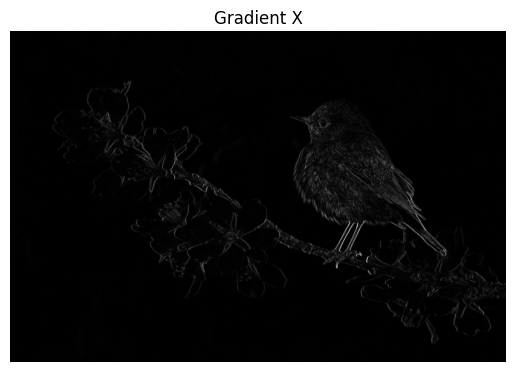

In [ ]:
# Compute x-directional derivative
grad_x = convolve_3x3(img_gray, sobel_x)

plt.imshow(np.abs(grad_x), cmap="gray")
plt.title("Gradient X")
plt.axis("off")
plt.show()

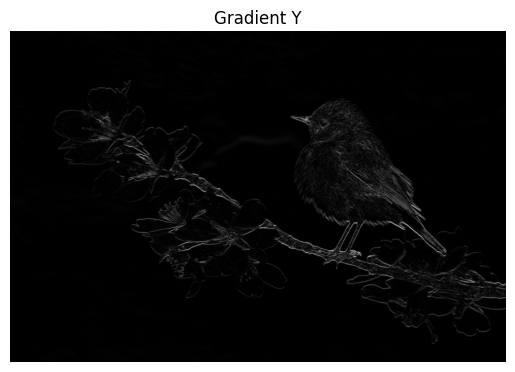

In [ ]:
# Compute y-directional derivative
grad_y = convolve_3x3(img_gray, sobel_y)

plt.imshow(np.abs(grad_y), cmap="gray")
plt.title("Gradient Y")
plt.axis("off")
plt.show()

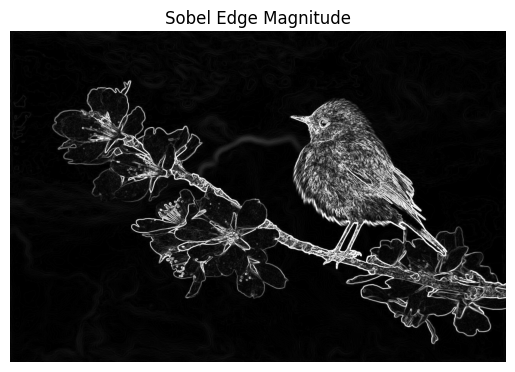

In [ ]:
# Compute gradient magnitude
grad_mag = np.sqrt(grad_x**2 + grad_y**2)

# Clip to displayable pixel range
grad_mag = np.clip(grad_mag, 0, 255).astype(np.uint8)

plt.imshow(grad_mag, cmap="gray")
plt.title("Sobel Edge Magnitude")
plt.axis("off")
plt.show()

In [ ]:
print("Image shape:", img_gray.shape)
print("Gradient magnitude shape:", grad_mag.shape)

Image shape: (853, 1280)
Gradient magnitude shape: (853, 1280)


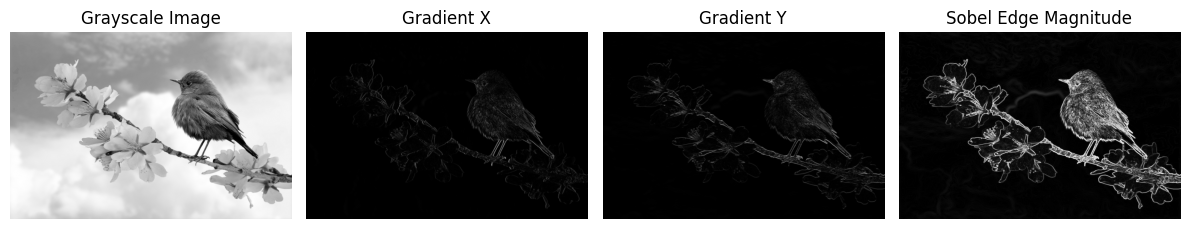

In [ ]:
# Display all results side by side for comparison
plt.figure(figsize=(12, 4))

plt.subplot(1, 4, 1)
plt.imshow(img_gray, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(np.abs(grad_x), cmap="gray")
plt.title("Gradient X")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(np.abs(grad_y), cmap="gray")
plt.title("Gradient Y")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(grad_mag, cmap="gray")
plt.title("Sobel Edge Magnitude")
plt.axis("off")

plt.tight_layout()
plt.show()